# compare_models.ipynb
Multi-model comparison: per-perturbation predicted vs actual scRNA expression.

Supports any number of scGPT model variants (vanilla or GRN-biased) by pointing to their save directories.
Auto-detects model type: if `M_aligned.npy` exists in the save dir → GRN-biased; otherwise → vanilla.

In [13]:
import sys, os, warnings, glob
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr
from scipy import sparse
from torch import nn

import scgpt as scg
from scgpt.model import TransformerGenerator
from scgpt.tokenizer import GeneVocab
from scgpt.utils import map_raw_id_to_vocab_id

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

Device: cuda


## USER CONFIG — edit this cell

In [14]:
# ============================================================
# Add as many models as you like.
# 'save_dir' : path to the model's save directory
# 'label'    : display name in plots
# 'color'    : matplotlib color
# ============================================================
MODEL_CONFIGS = [
    {
        'save_dir': './save/dev_perturb_norman_leakfix-Mar05-20-28',
        'label': 'S1 vanilla (leakfix)',
        'color': '#2196F3',
    },
    {
        'save_dir': './save/dev_perturb_norman_grn_bias-Mar06-12-39',
        'label': 'S2 GRN bias',
        'color': '#FF9800',
    },
    # Add more models here, e.g.:
    {'save_dir': './save/norman_grn_bias_weight_v2-Mar06-17-21',
     'label': 'S2 V2', 'color': '#4CAF50'},
]

# Data + pretrained checkpoint
DATA_PATH   = '../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad'
MODEL_DIR   = '../../model_checkpoints/scGPT_human'

# Perturbations to visualize in detail (leave empty [] to auto-pick)
SHOW_PERTS = [
    'CEBPB+MAPK1',
    'ETS2+MAPK1',
    'BCL2L11+TGFBR2',
    'DUSP9+KLF1',
    'CEBPE+SPI1',
]

# Number of control cells to pool for inference
POOL_SIZE = 100

# Architecture constants (must match training)
EMBSIZE, D_HID, NLAYERS, NHEAD = 128, 512, 4, 4
N_LAYERS_CLS = 3
DROPOUT = 0.2
AMP = True
PAD_TOKEN = '<pad>'
SPECIAL_TOKENS = [PAD_TOKEN, '<cls>', '<eoc>']

## 1. Load & preprocess data (shared across all models)

In [15]:
adata = sc.read_h5ad(DATA_PATH)
adata.obs['split'] = adata.obs['gears_split']
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
if 'gene_name' in adata.var:
    adata.var.set_index('gene_name', inplace=True)
    adata.var_names_make_unique()

# Leak-fixed HVG selection (training-split only) — same as S1/S2 training
train_adata = adata[adata.obs['split'] == 'train'].copy()
train_perturbed_genes = set()
for cond in train_adata.obs['condition'].unique():
    if cond != 'ctrl':
        for p in cond.split('+'):
            if p != 'ctrl':
                train_perturbed_genes.add(p)

sc.pp.highly_variable_genes(train_adata, n_top_genes=1200, flavor='seurat', subset=False)
hvg_genes = set(train_adata.var[train_adata.var['highly_variable']].index)
hvg_genes.update(train_perturbed_genes & set(adata.var_names))
adata.var['highly_variable'] = adata.var_names.isin(hvg_genes)
adata = adata[:, adata.var['highly_variable']].copy()

# Control pool (train only)
ctrl_adata = adata[(adata.obs['condition'] == 'ctrl') & (adata.obs['split'] == 'train')].copy()
ctrl_X_pool = ctrl_adata.X.toarray() if sparse.issparse(ctrl_adata.X) else ctrl_adata.X

# Global control mean (over all control cells)
all_ctrl = adata[adata.obs['condition'] == 'ctrl']
all_ctrl_X = all_ctrl.X.toarray() if sparse.issparse(all_ctrl.X) else all_ctrl.X
ctrl_mean = all_ctrl_X.mean(axis=0)

genes = adata.var_names.tolist()
n_genes = len(genes)
gene_to_idx = {g: i for i, g in enumerate(genes)}

print(f'adata: {adata.shape}, genes: {n_genes}')
print(f'Control pool (train only): {ctrl_X_pool.shape[0]} cells')

adata: (89357, 1251), genes: 1251
Control pool (train only): 7353 cells


## 2. Vocabulary + gene ID mapping

In [16]:
vocab_file = Path(MODEL_DIR) / 'vocab.json'
vocab = GeneVocab.from_file(vocab_file)
for s in SPECIAL_TOKENS:
    if s not in vocab:
        vocab.append_token(s)

gene_ids = np.array(
    [vocab[g] if g in vocab else vocab[PAD_TOKEN] for g in genes], dtype=int
)
ntokens = len(vocab)
n_matched = sum(1 for g in genes if g in vocab)
print(f'Vocab match: {n_matched}/{n_genes} genes')

Vocab match: 1146/1251 genes


## 3. Model definitions & loader

In [17]:
# ---- GRNAttentionBias (needed for GRN-biased models) ----
class GRNAttentionBias(nn.Module):
    """Wraps nn.MultiheadAttention to inject GRN prior bias: score += alpha * M[i,j]"""
    def __init__(self, original_attn, M_grn, alpha):
        super().__init__()
        self.original_attn = original_attn
        self.M_grn = M_grn
        self.alpha = alpha
        self._current_gene_indices = None

    def __getattr__(self, name):
        try:
            return super().__getattr__(name)
        except AttributeError:
            orig = self.__dict__.get('_modules', {}).get('original_attn')
            if orig is not None:
                return getattr(orig, name)
            raise

    def forward(self, query, key, value, key_padding_mask=None,
                need_weights=False, attn_mask=None, **kwargs):
        seq_len = query.size(0)
        if self._current_gene_indices is not None:
            idx = self._current_gene_indices
            grn_bias = self.alpha * self.M_grn[idx][:, idx]
        else:
            grn_bias = self.alpha * self.M_grn[:seq_len, :seq_len]
        attn_mask = grn_bias if attn_mask is None else attn_mask + grn_bias
        return self.original_attn(
            query, key, value,
            key_padding_mask=key_padding_mask,
            need_weights=need_weights,
            attn_mask=attn_mask, **kwargs
        )


def set_gene_indices_on_model(model_bundle, gene_indices):
    """Set active gene indices on all patched attention layers."""
    for attn in model_bundle.get('patched_attns', []):
        attn._current_gene_indices = gene_indices


def load_model(cfg):
    """
    Load a model from a save directory.
    Auto-detects vanilla vs GRN-biased by presence of M_aligned.npy.
    Returns a bundle dict: {model, label, color, patched_attns, is_grn}
    """
    save_dir = Path(cfg['save_dir'])
    model_pt  = save_dir / 'best_model.pt'
    M_path    = save_dir / 'M_aligned.npy'
    is_grn    = M_path.exists()

    # Build base model
    base = TransformerGenerator(
        ntokens, EMBSIZE, NHEAD, D_HID, NLAYERS,
        nlayers_cls=N_LAYERS_CLS, n_cls=1, vocab=vocab, dropout=DROPOUT,
        pad_token=PAD_TOKEN, pad_value=0, pert_pad_id=0,
        use_fast_transformer=False,
    )

    patched_attns = []

    if is_grn:
        # Patch attention layers before loading weights
        M_aligned = np.load(M_path).astype(np.float32)
        M_tensor  = torch.tensor(M_aligned, dtype=torch.float32, device=device)
        alpha_param = nn.Parameter(torch.tensor(0.1, dtype=torch.float32))
        for layer in base.transformer_encoder.layers:
            wrapped = GRNAttentionBias(layer.self_attn, M_tensor, alpha_param)
            layer.self_attn = wrapped
            patched_attns.append(wrapped)
        base.alpha_grn = alpha_param
        print(f'[{cfg["label"]}] GRN-biased model, M={M_aligned.shape}')
    else:
        print(f'[{cfg["label"]}] Vanilla model')

    # Load fine-tuned weights
    state = torch.load(model_pt, map_location=device)
    base.load_state_dict(state, strict=False)
    base.to(device)
    base.eval()

    if is_grn:
        print(f'  alpha = {base.alpha_grn.item():.4f}')

    return {
        'model':        base,
        'label':        cfg['label'],
        'color':        cfg['color'],
        'patched_attns': patched_attns,
        'is_grn':       is_grn,
        'save_dir':     save_dir,
    }

In [18]:
# Load all models
bundles = [load_model(cfg) for cfg in MODEL_CONFIGS]
print(f'\nLoaded {len(bundles)} models:')
for b in bundles:
    print(f'  [{b["label"]}]  GRN={b["is_grn"]}  dir={b["save_dir"].name}')

[S1 vanilla (leakfix)] Vanilla model
[S2 GRN bias] GRN-biased model, M=(1251, 1251)
  alpha = 0.0993
[S2 V2] GRN-biased model, M=(1251, 1251)
  alpha = 14.1231

Loaded 3 models:
  [S1 vanilla (leakfix)]  GRN=False  dir=dev_perturb_norman_leakfix-Mar05-20-28
  [S2 GRN bias]  GRN=True  dir=dev_perturb_norman_grn_bias-Mar06-12-39
  [S2 V2]  GRN=True  dir=norman_grn_bias_weight_v2-Mar06-17-21


## 4. Inference function

In [19]:
def predict_perturbation(bundle, pert, pool_size=POOL_SIZE):
    """
    Run model inference for a single perturbation.
    Returns predicted mean expression vector (n_genes,).
    """
    model = bundle['model']
    model.eval()

    pool = min(pool_size, ctrl_X_pool.shape[0])
    idx_pool = np.random.choice(ctrl_X_pool.shape[0], pool, replace=False)
    base_expr = torch.tensor(ctrl_X_pool[idx_pool], dtype=torch.float32)

    pert_flags = torch.zeros(n_genes, dtype=torch.long)
    for p in pert.split('+'):
        if p != 'ctrl' and p in gene_to_idx:
            pert_flags[gene_to_idx[p]] = 1

    input_gene_ids = torch.arange(n_genes, device=device, dtype=torch.long)
    mapped_ids = map_raw_id_to_vocab_id(input_gene_ids, gene_ids).to(device)
    mapped_ids = mapped_ids.repeat(pool, 1)

    set_gene_indices_on_model(bundle, input_gene_ids)

    input_values  = base_expr.to(device)
    input_pert    = pert_flags.unsqueeze(0).repeat(pool, 1).to(device)
    src_mask      = torch.zeros_like(input_values, dtype=torch.bool)

    with torch.no_grad(), torch.cuda.amp.autocast(enabled=AMP):
        out = model(
            mapped_ids, input_values, input_pert,
            src_key_padding_mask=src_mask,
            CLS=False, CCE=False, MVC=False, ECS=False,
        )
        preds = out['mlm_output'].cpu().numpy()

    return preds.mean(axis=0)  # (n_genes,)


def additive_baseline(pert):
    """
    Additive baseline: delta_a + delta_b + ctrl_mean.
    Returns predicted mean expression vector (n_genes,).
    """
    parts = [p for p in pert.split('+') if p != 'ctrl']
    delta_sum = np.zeros(n_genes)
    for p in parts:
        single_mask = adata.obs['condition'] == p + '+ctrl'
        if single_mask.sum() == 0:
            single_mask = adata.obs['condition'] == 'ctrl+' + p
        if single_mask.sum() == 0:
            single_mask = adata.obs['condition'] == p
        if single_mask.sum() > 0:
            X_s = adata[single_mask].X
            if sparse.issparse(X_s): X_s = X_s.toarray()
            delta_sum += X_s.mean(axis=0) - ctrl_mean
    return ctrl_mean + delta_sum


print('Inference functions ready.')

Inference functions ready.


## 5. Select perturbations to visualize

In [20]:
# Load per-perturbation results from all models (PCC, MSE)
all_results = {}
for b in bundles:
    csv = b['save_dir'] / 'per_perturbation_results.csv'
    if csv.exists():
        df = pd.read_csv(csv)
        all_results[b['label']] = df.set_index('perturbation')

# Test-set perturbations
test_conds = set(adata[adata.obs['split'] == 'test'].obs['condition'].unique())
test_conds.discard('ctrl')

if SHOW_PERTS:
    perts_to_plot = [p for p in SHOW_PERTS if p in test_conds]
    missing = [p for p in SHOW_PERTS if p not in test_conds]
    if missing:
        print(f'WARNING: not in test set: {missing}')
else:
    # Auto-pick: 3 combos with largest variance in PCC across models
    combo_conds = [c for c in test_conds if '+' in c and 'ctrl' not in c]
    if len(all_results) > 1:
        labels = list(all_results.keys())
        dfs = [all_results[l] for l in labels]
        shared = list(set(dfs[0].index) & set(dfs[1].index) & set(combo_conds))
        variance = pd.DataFrame(
            {l: all_results[l].loc[shared, 'pcc_top20'] for l in labels if shared}
        ).var(axis=1)
        perts_to_plot = variance.nlargest(5).index.tolist()
    else:
        perts_to_plot = combo_conds[:5]

print(f'Perturbations to plot: {perts_to_plot}')

Perturbations to plot: ['CEBPB+MAPK1', 'ETS2+MAPK1', 'BCL2L11+TGFBR2', 'DUSP9+KLF1', 'CEBPE+SPI1']


## 6. Per-perturbation comparison plots
For each selected perturbation: top-20 DE genes bar chart + scatter (predicted vs actual delta)

In [21]:
def get_actual_delta(pert):
    """Return (cells x genes) delta matrix and per-cell rows for a condition."""
    mask = adata.obs['condition'] == pert
    X = adata[mask].X
    if sparse.issparse(X): X = X.toarray()
    return X - ctrl_mean  # (n_cells, n_genes)


def plot_perturbation_case(pert, bundles, ax_bar, ax_scatter, pool_size=POOL_SIZE):
    """
    Left panel (ax_bar):     top-20 DE genes — actual delta (box) + each model (dot/line)
    Right panel (ax_scatter): all-gene scatter — predicted delta vs actual delta per model
    """
    actual_delta_cells = get_actual_delta(pert)        # (n_cells, n_genes)
    actual_delta_mean  = actual_delta_cells.mean(axis=0)  # (n_genes,)

    # Top-20 genes by |actual delta|
    top20_idx   = np.argsort(np.abs(actual_delta_mean))[-20:]
    top20_genes = [genes[i] for i in top20_idx]
    top20_actual_mean = actual_delta_mean[top20_idx]

    # Additive baseline
    add_pred    = additive_baseline(pert)
    add_delta   = add_pred - ctrl_mean

    # Run inference for each model
    model_preds = {}
    for b in bundles:
        pred_expr = predict_perturbation(b, pert, pool_size=pool_size)
        model_preds[b['label']] = pred_expr - ctrl_mean   # (n_genes,)

    # ---- BAR PANEL: top-20 gene expression changes ----
    x = np.arange(len(top20_idx))
    n_models = len(bundles)

    # Actual: boxplot over cells
    ax_bar.boxplot(
        actual_delta_cells[:, top20_idx],
        positions=x, widths=0.45,
        showfliers=False, patch_artist=True,
        boxprops=dict(facecolor='#E0E0E0', alpha=0.8),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(alpha=0.5),
        capprops=dict(alpha=0.5),
    )

    # Additive baseline
    ax_bar.plot(x, add_delta[top20_idx], 'D--', color='gray',
                markersize=5, linewidth=1, alpha=0.8, label='Additive baseline', zorder=3)

    # Each model prediction
    offsets = np.linspace(-0.15, 0.15, n_models)
    for i, b in enumerate(bundles):
        delta = model_preds[b['label']]
        pcc_val = ''
        if b['label'] in all_results and pert in all_results[b['label']].index:
            pcc_val = f" PCC={all_results[b['label']].loc[pert,'pcc_top20']:.2f}"
        ax_bar.scatter(x + offsets[i], delta[top20_idx],
                       color=b['color'], s=40, zorder=4,
                       label=b['label'] + pcc_val, edgecolors='k', linewidths=0.3)

    ax_bar.axhline(0, color='black', lw=0.8, ls=':')
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(top20_genes, rotation=60, ha='right', fontsize=7)
    ax_bar.set_ylabel('Delta expression (log-normalized)')
    ax_bar.set_title(f'{pert} — top-20 DE genes', fontweight='bold')
    ax_bar.legend(fontsize=7, loc='upper left')

    # ---- SCATTER PANEL: all genes predicted vs actual delta ----
    for b in bundles:
        delta = model_preds[b['label']]
        r, _ = pearsonr(delta, actual_delta_mean)
        ax_scatter.scatter(actual_delta_mean, delta,
                           color=b['color'], alpha=0.4, s=10,
                           label=f"{b['label']} r={r:.2f}")

    # Additive
    r_add, _ = pearsonr(add_delta, actual_delta_mean)
    ax_scatter.scatter(actual_delta_mean, add_delta, color='gray',
                       alpha=0.3, s=8, label=f'Additive r={r_add:.2f}')

    # Top-20 genes highlighted
    ax_scatter.scatter(actual_delta_mean[top20_idx],
                       [model_preds[bundles[0]['label']][i] for i in top20_idx],
                       color='red', s=25, zorder=5, alpha=0.7, label='top-20 (model 1)')

    lim = max(np.abs(actual_delta_mean).max(), 0.5) * 1.1
    ax_scatter.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.3, lw=0.8)
    ax_scatter.set_xlim(-lim, lim)
    ax_scatter.set_xlabel('Actual delta')
    ax_scatter.set_ylabel('Predicted delta')
    ax_scatter.set_title('All genes: predicted vs actual', fontweight='bold')
    ax_scatter.legend(fontsize=7)
    sns.despine(ax=ax_bar)
    sns.despine(ax=ax_scatter)

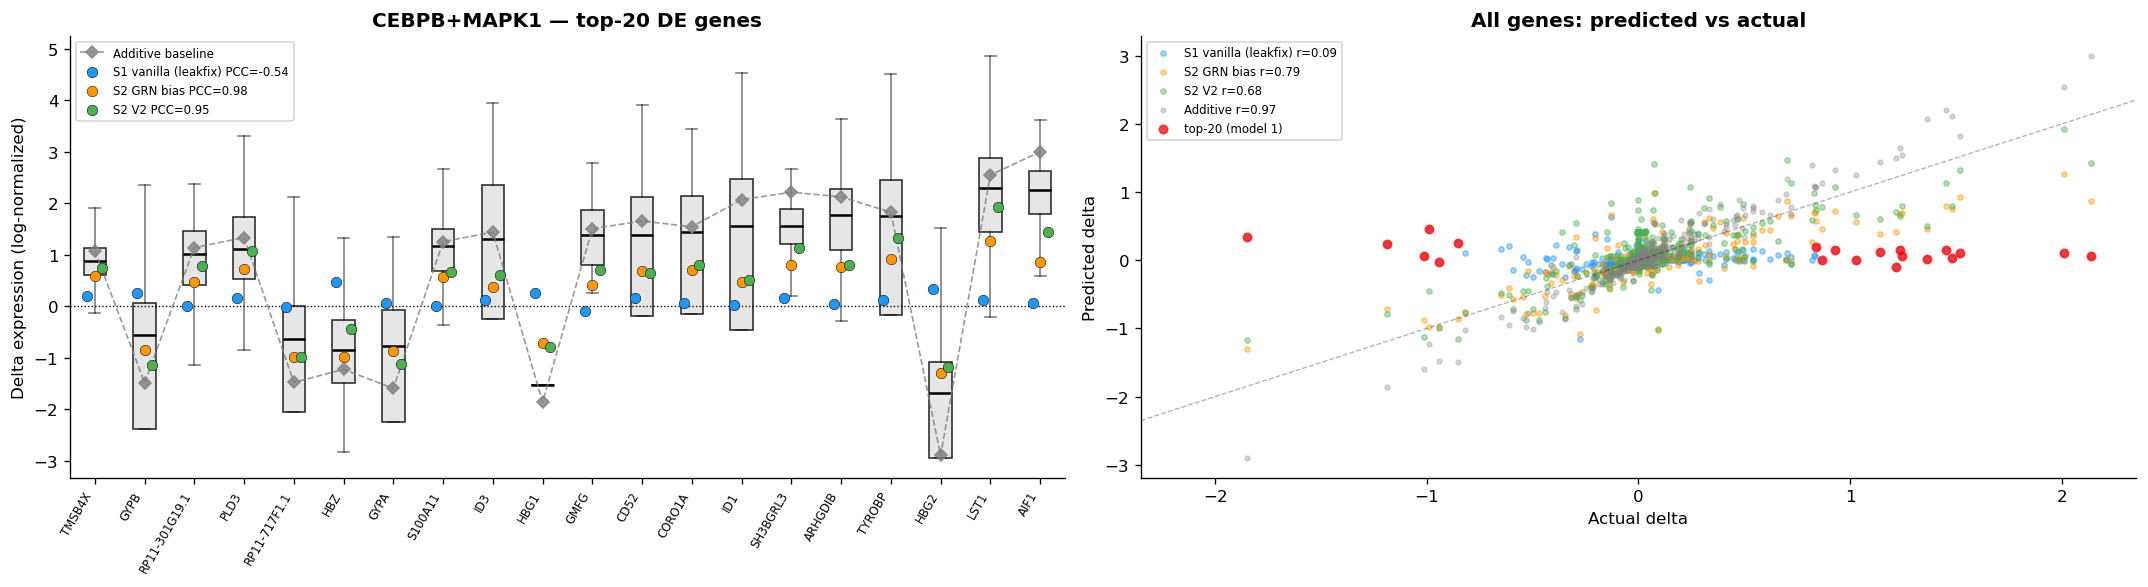

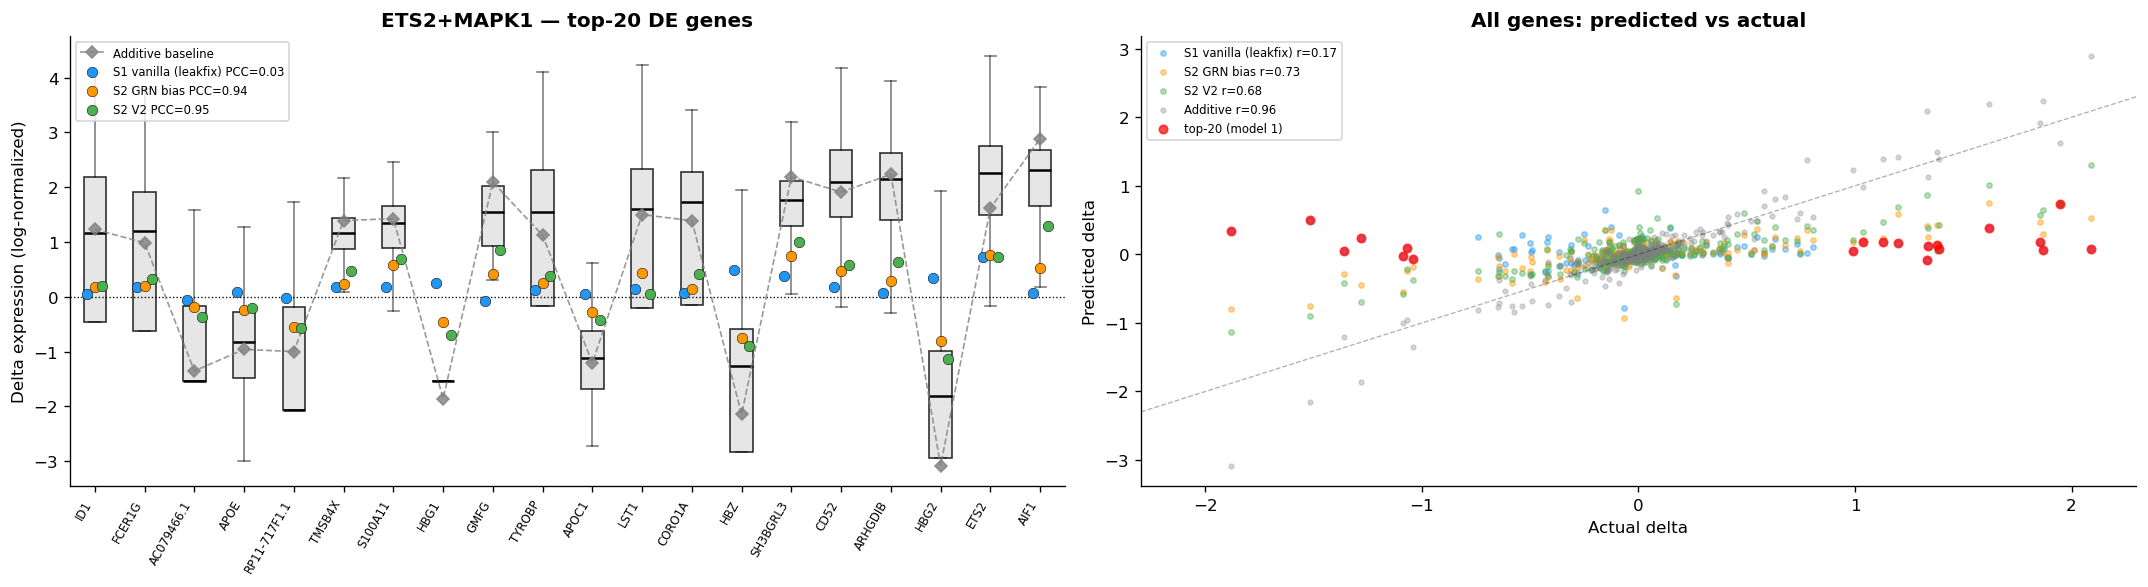

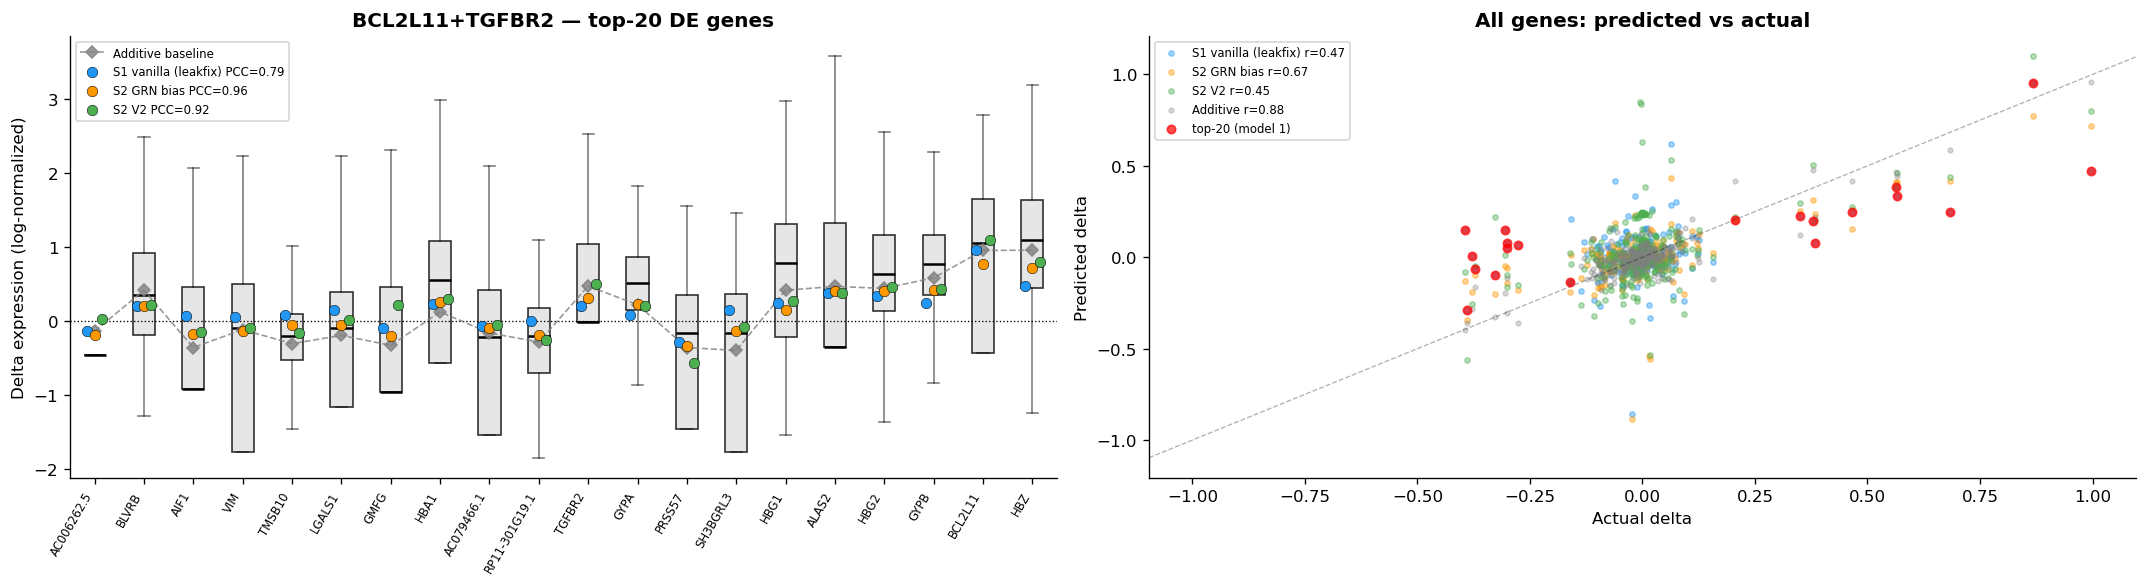

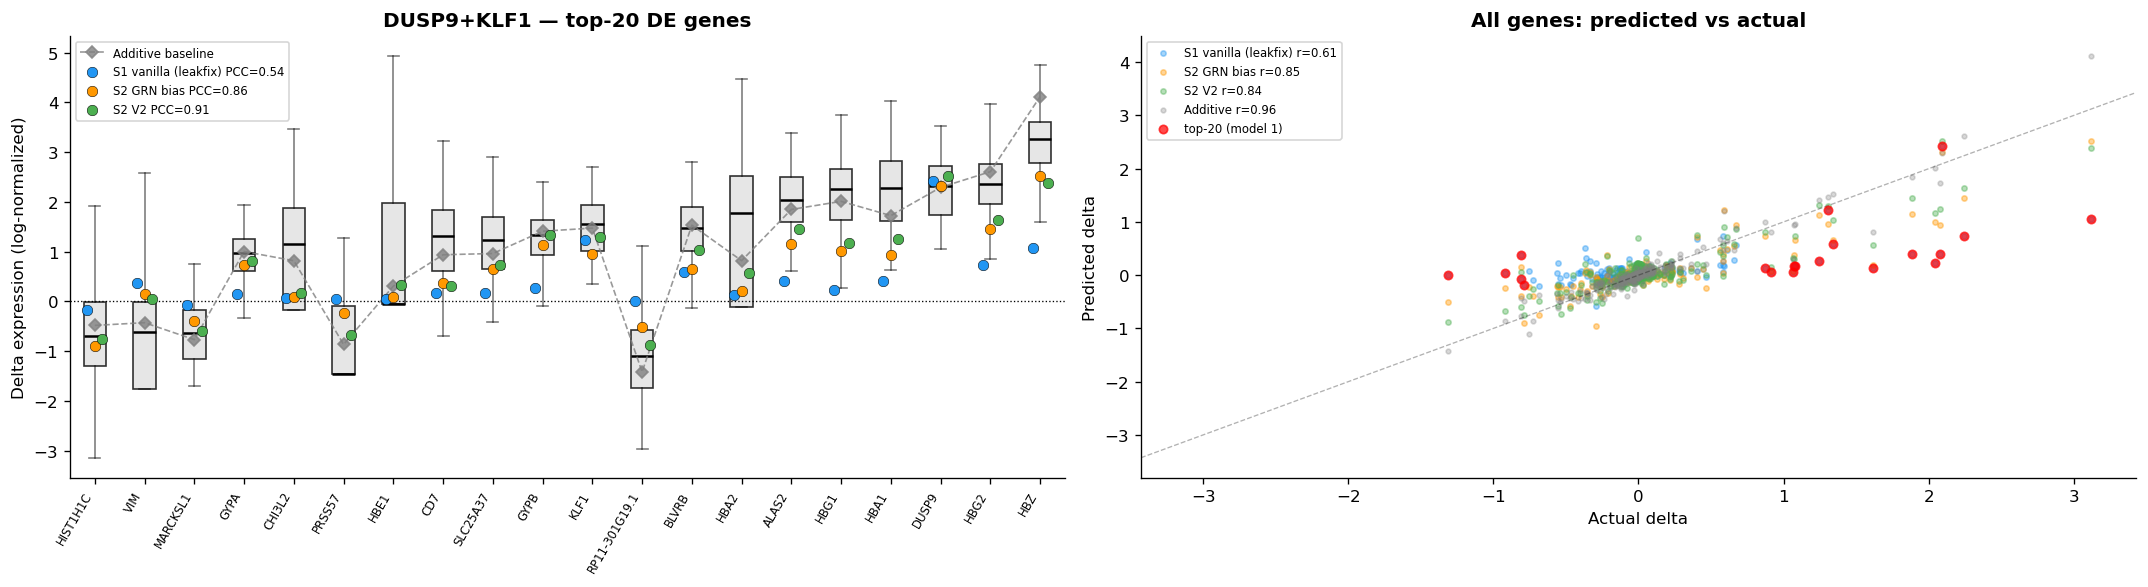

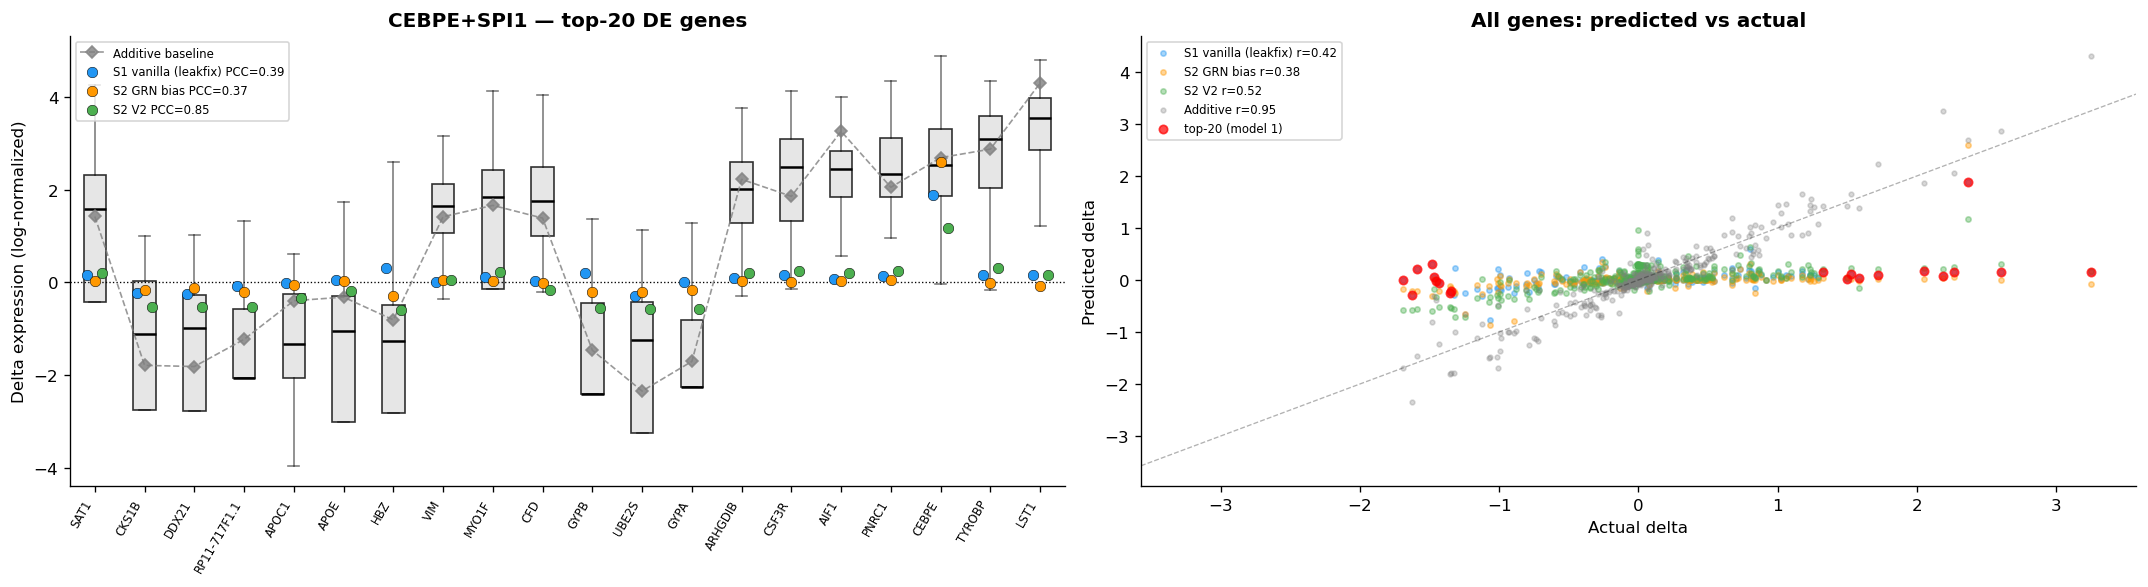

In [22]:
np.random.seed(42)  # reproducible control pool sampling

for pert in perts_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    plot_perturbation_case(pert, bundles, axes[0], axes[1])
    plt.tight_layout()
    plt.show()
    print()

## 7. Summary: PCC distribution per model

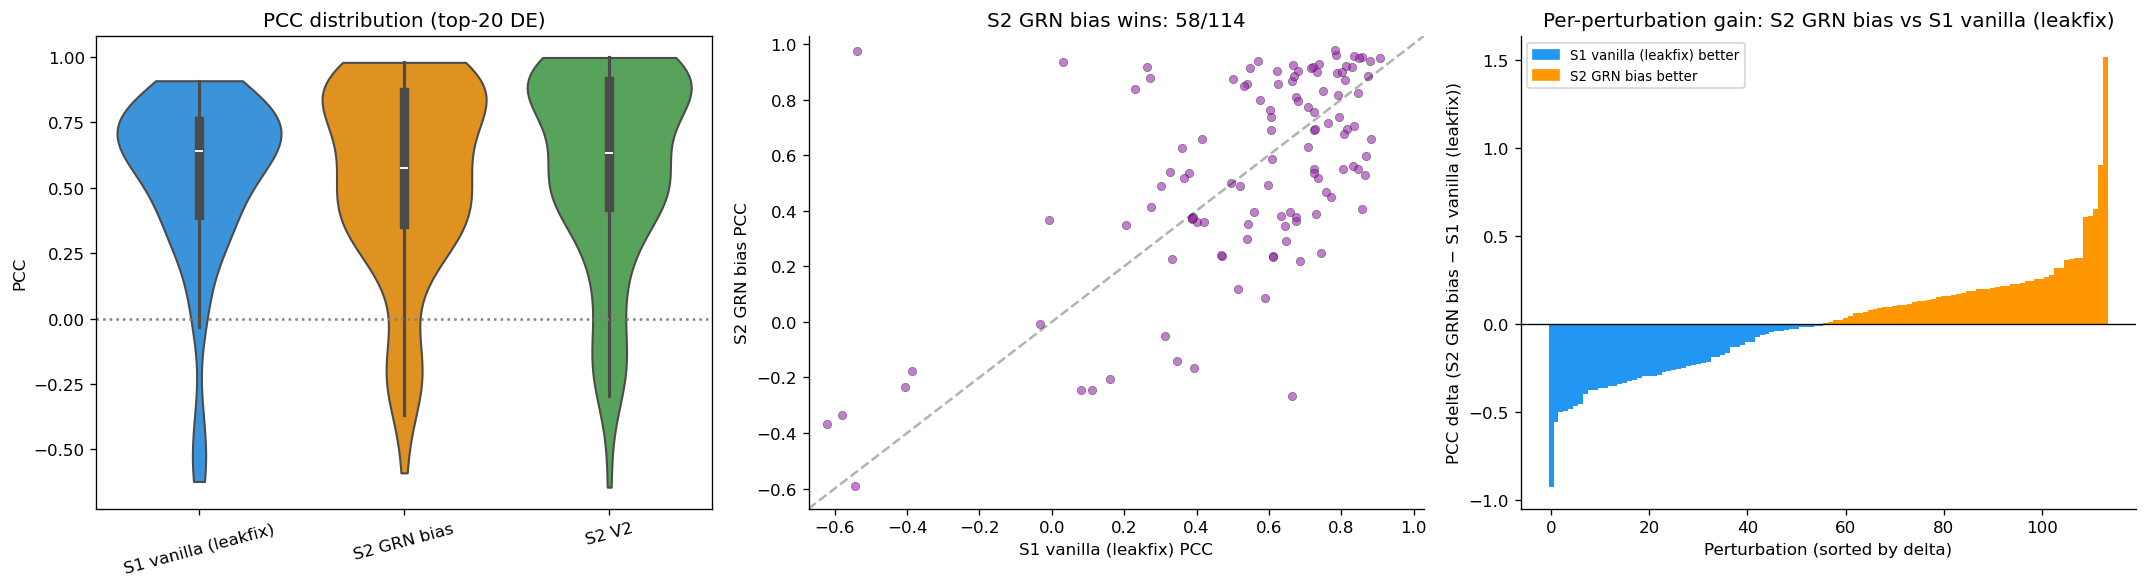


=== SUMMARY TABLE ===
Model                                 Mean PCC   Median      Std
-----------------------------------------------------------------
S1 vanilla (leakfix)                    0.5411   0.6395   0.3278
S2 GRN bias                             0.5379   0.5737   0.3645
S2 V2                                   0.5872   0.6324   0.3728


In [23]:
if len(all_results) >= 2:
    labels = [b['label'] for b in bundles if b['label'] in all_results]
    shared_perts = set.intersection(*[set(all_results[l].index) for l in labels])
    shared_perts = sorted(shared_perts)

    pcc_data = {l: all_results[l].loc[shared_perts, 'pcc_top20'].values for l in labels}
    colors    = {b['label']: b['color'] for b in bundles}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ---- Violin / box ----
    df_long = pd.DataFrame(pcc_data).melt(var_name='Model', value_name='PCC')
    sns.violinplot(data=df_long, x='Model', y='PCC',
                   palette={l: colors[l] for l in labels},
                   inner='box', ax=axes[0], cut=0)
    axes[0].set_title('PCC distribution (top-20 DE)')
    axes[0].set_xlabel('')
    axes[0].axhline(0, ls=':', c='gray')
    for tick in axes[0].get_xticklabels():
        tick.set_rotation(15)

    # ---- Pairwise scatter (first 2 models) ----
    l0, l1 = labels[0], labels[1]
    ax = axes[1]
    ax.scatter(pcc_data[l0], pcc_data[l1], alpha=0.6, s=25,
               color='#9C27B0', edgecolors='k', linewidths=0.3)
    lim = [min(pcc_data[l0].min(), pcc_data[l1].min()) - 0.05,
           max(pcc_data[l0].max(), pcc_data[l1].max()) + 0.05]
    ax.plot(lim, lim, 'k--', alpha=0.3)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f'{l0} PCC')
    ax.set_ylabel(f'{l1} PCC')
    n_l1_wins = (pcc_data[l1] > pcc_data[l0]).sum()
    ax.set_title(f'{l1} wins: {n_l1_wins}/{len(shared_perts)}')
    sns.despine(ax=ax)

    # ---- Delta bar: model1 vs model2 per perturbation (sorted) ----
    delta = pcc_data[l1] - pcc_data[l0]
    order = np.argsort(delta)
    bar_colors = [colors[l1] if d > 0 else colors[l0] for d in delta[order]]
    axes[2].bar(range(len(delta)), delta[order], color=bar_colors, width=1.0)
    axes[2].axhline(0, color='black', lw=0.8)
    axes[2].set_xlabel('Perturbation (sorted by delta)')
    axes[2].set_ylabel(f'PCC delta ({l1} − {l0})')
    axes[2].set_title(f'Per-perturbation gain: {l1} vs {l0}')
    patch0 = mpatches.Patch(color=colors[l0], label=f'{l0} better')
    patch1 = mpatches.Patch(color=colors[l1], label=f'{l1} better')
    axes[2].legend(handles=[patch0, patch1], fontsize=8)
    sns.despine(ax=axes[2])

    plt.tight_layout()
    plt.show()

    # Summary table
    print('\n=== SUMMARY TABLE ===')
    print(f'{"Model":<35} {"Mean PCC":>10} {"Median":>8} {"Std":>8}')
    print('-' * 65)
    for l in labels:
        v = pcc_data[l]
        print(f'{l:<35} {v.mean():>10.4f} {np.median(v):>8.4f} {v.std():>8.4f}')
else:
    print('Need >= 2 models with saved results for summary comparison.')

## 8. Head-to-head table: per perturbation

In [24]:
if len(all_results) >= 2:
    labels = [b['label'] for b in bundles if b['label'] in all_results]
    shared_perts = sorted(set.intersection(*[set(all_results[l].index) for l in labels]))

    table = pd.DataFrame({'perturbation': shared_perts})
    for l in labels:
        table[l + '_pcc'] = all_results[l].loc[shared_perts, 'pcc_top20'].values
        table[l + '_mse'] = all_results[l].loc[shared_perts, 'mse_top20'].values

    # Best model per row
    pcc_cols = [l + '_pcc' for l in labels]
    table['best_model'] = table[pcc_cols].idxmax(axis=1).str.replace('_pcc', '')

    print(f'Best model wins per perturbation:')
    print(table['best_model'].value_counts().to_string())
    print()

    # Show cases where models disagree most
    if len(labels) >= 2:
        table['pcc_delta'] = table[labels[1] + '_pcc'] - table[labels[0] + '_pcc']
        print(f'Top 10 cases where {labels[1]} most improved vs {labels[0]}:')
        display(table.nlargest(10, 'pcc_delta')[['perturbation'] + pcc_cols + ['pcc_delta']])
        print(f'\nTop 10 cases where {labels[1]} most regressed vs {labels[0]}:')
        display(table.nsmallest(10, 'pcc_delta')[['perturbation'] + pcc_cols + ['pcc_delta']])

    table.to_csv('compare_models_per_perturbation.csv', index=False)
    print('\nSaved: compare_models_per_perturbation.csv')

Best model wins per perturbation:
best_model
S2 V2                   50
S1 vanilla (leakfix)    44
S2 GRN bias             20

Top 10 cases where S2 GRN bias most improved vs S1 vanilla (leakfix):


,perturbation,S1 vanilla (leakfix)_pcc,S2 GRN bias_pcc,S2 V2_pcc,pcc_delta
11,CEBPB+MAPK1,-0.537464,0.975884,0.949671,1.513348
28,ETS2+MAPK1,0.030585,0.935095,0.952781,0.904511
101,ZBTB10+SNAI1,0.264295,0.918140,0.959821,0.653846
26,ETS2+CEBPE,0.229036,0.839080,0.925009,0.610044
87,TGFBR2+ETS2,0.271108,0.876584,0.912692,0.605476
89,TMSB4X+BAK1,-0.007043,0.367807,-0.157760,0.374850
94,UBASH3B+OSR2,0.501611,0.874878,0.745185,0.373267
93,UBASH3B+CNN1,0.568776,0.936817,0.984253,0.368041
23,DUSP9+PRTG,0.547856,0.912316,0.962101,0.364460
51,MAP2K3+IKZF3,0.531118,0.848884,0.934642,0.317766



Top 10 cases where S2 GRN bias most regressed vs S1 vanilla (leakfix):


,perturbation,S1 vanilla (leakfix)_pcc,S2 GRN bias_pcc,S2 V2_pcc,pcc_delta
33,FOSB+PTPN12,0.663197,-0.266196,-0.073799,-0.929393
2,ARRDC3+ctrl,0.393922,-0.166590,0.129815,-0.560512
46,KIF18B+ctrl,0.588060,0.085456,0.173066,-0.502605
65,PRDM1+CBFA2T3,0.744200,0.248604,0.046514,-0.495596
92,TSC22D1+ctrl,0.346288,-0.139653,0.069121,-0.485941
111,ctrl+SPI1,0.685863,0.219846,0.500349,-0.466017
66,PRDM1+ctrl,0.858626,0.404327,0.495446,-0.454299
18,CNN1+MAPK1,0.516050,0.116603,0.201197,-0.399447
84,SPI1+ctrl,0.611605,0.234292,0.433895,-0.377313
31,FEV+MAP7D1,0.611761,0.235742,0.375318,-0.376019



Saved: compare_models_per_perturbation.csv
